# Ensemble sin Leakage — modelos_45 (ventana = 45)

Mismo flujo que `ensemble_nueva_info.ipynb` pero usando los modelos entrenados con **ventana de 45 pasos** (`modelos_45/`).

**Diferencias respecto al notebook de ventana 200:**
- `INPUT_SIZE = OUTPUT_SIZE = 45`
- Modelos cargados desde `modelos_45/` (`*45.keras`)
- Cache separado: `cache_modelos_45/`

**Flujo sin leakage (igual que antes):**
1. Modelos predicen sobre **todo el 30%** (out-of-sample genuino).
2. Ventanas del 30% partidas en **dos mitades**:
   - `ens_fit` (50%) → para optimizar pesos del ensemble
   - `held_out` (50%) → evaluación final que **nadie** tocó jamás

$$\text{df\_70 (100\%)} \xrightarrow{\text{profe}} \text{Modelos entrenados}$$
$$\text{df\_30} \xrightarrow{\text{predict}} \begin{cases} \text{50\%} \to \text{fit ensemble weights} \\ \text{50\%} \to \text{held-out final eval} \end{cases}$$

In [ ]:
# Dependencias extra (keras-tcn no viene preinstalado en Colab)
!pip install -q keras-tcn

In [40]:
import os
import sys
import importlib
import shutil
import glob

# ---- Colab: clonar repo y localizar modelos_45/ ----
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    os.chdir('/content')
    if not os.path.exists('heartrate-forecasting'):
        !git clone https://github.com/AllanDBB/heartrate-forecasting.git
    os.chdir('heartrate-forecasting')

    repo_m45 = os.path.join(os.getcwd(), 'modelos_45')
    os.makedirs(repo_m45, exist_ok=True)

    # Buscar *45.keras en ubicaciones conocidas de Colab
    search_dirs = [
        '/content/modelos_45',
        '/content/drive/MyDrive/modelos_45',
        '/content/drive/MyDrive',
    ]
    for sdir in search_dirs:
        if not os.path.isdir(sdir):
            continue
        for f in glob.glob(os.path.join(sdir, '*45.keras')):
            dst = os.path.join(repo_m45, os.path.basename(f))
            if not os.path.exists(dst):
                shutil.copy2(f, dst)
                print(f'  Copiado: {f} -> {dst}')

    found = glob.glob(os.path.join(repo_m45, '*.keras'))
    if len(found) < 6:
        print(f'\n⚠️  Solo se encontraron {len(found)}/6 modelos .keras')
        print('   Subiendo via upload interactivo...\n')
        from google.colab import files
        uploaded = files.upload()  # el usuario arrastra los *45.keras aqui
        for fname, data in uploaded.items():
            dest = os.path.join(repo_m45, fname)
            with open(dest, 'wb') as fh:
                fh.write(data)
            print(f'  Guardado: {dest} ({len(data)/1e6:.1f} MB)')

    found = glob.glob(os.path.join(repo_m45, '*.keras'))
    print(f'\nModelos en modelos_45/: {len(found)}/6')
    for f in sorted(found):
        print(f'  {os.path.basename(f):20s} {os.path.getsize(f)/1e6:.1f} MB')
    assert len(found) >= 6, f'Faltan modelos. Encontrados: {[os.path.basename(f) for f in found]}'

if not IN_COLAB:
    try:
        _nb_path = __vsc_ipynb_file__
        REPO_DIR = os.path.dirname(os.path.dirname(os.path.abspath(_nb_path)))
    except NameError:
        REPO_DIR = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
else:
    REPO_DIR = os.getcwd()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
print(f'\nREPO_DIR: {REPO_DIR}')
print(f'Colab: {IN_COLAB}')

import main
import utils
importlib.reload(utils)
importlib.reload(main)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



REPO_DIR: c:\Users\allan\OneDrive\Documentos\Asistencia 2026 I
Colab: False


## 1. Verificación de particiones y semilla

In [2]:
# Cargar particiones del profe (nueva_info)
df70_nueva = utils.read_split_dataframe('nueva_info/df_70.csv')
df30_nueva = utils.read_split_dataframe('nueva_info/df_30.csv')

print('df_70:', df70_nueva.shape)
print('df_30:', df30_nueva.shape)

df_70: (1841, 93)
df_30: (1841, 41)


In [3]:
# Verificar semilla: _legacy_selectRandomColumns(seed=42) reproduce el split
df_full = utils.loadAllFiles('dataset')
print('Dataset completo:', df_full.shape)

df70_regen, df30_regen = utils._legacy_selectRandomColumns(df_full, seed=42)

match_70 = (set(df70_regen.columns) == set(df70_nueva.columns)
            and np.allclose(df70_regen[df70_nueva.columns].values,
                            df70_nueva.values, equal_nan=True))
match_30 = (set(df30_regen.columns) == set(df30_nueva.columns)
            and np.allclose(df30_regen[df30_nueva.columns].values,
                            df30_nueva.values, equal_nan=True))

print('Semilla 42 reproduce df_70?', match_70)
print('Semilla 42 reproduce df_30?', match_30)
print('Columnas solapadas:', sorted(set(df70_regen.columns) & set(df30_regen.columns)))

Alicia_Garreiro: 49 valores corregidos (vectorizado)
JJ_Olmos: 35 valores corregidos (vectorizado)
Salvardor_Cavas: 39 valores corregidos (vectorizado)
Abel_Rodriguez: 33 valores corregidos (vectorizado)
Lucia_Vidal: 38 valores corregidos (vectorizado)
Pepe: 40 valores corregidos (vectorizado)
Juan_Miguel_Morales: 35 valores corregidos (vectorizado)
Alba_Morlanes: 32 valores corregidos (vectorizado)
Marta_Baños: 239 valores corregidos (vectorizado)
Lorena_Caparros: 280 valores corregidos (vectorizado)
Lucia_Garcia: 355 valores corregidos (vectorizado)
Salvador_Cavas: 205 valores corregidos (vectorizado)
Carlota_Micallef: 318 valores corregidos (vectorizado)
Juan_Miguel_Morales: 337 valores corregidos (vectorizado)
Sara_Morlanes: 284 valores corregidos (vectorizado)
Lucia_Vidal: 250 valores corregidos (vectorizado)
Julia_Baños : 174 valores corregidos (vectorizado)
Carla_Martinez: 391 valores corregidos (vectorizado)
Alicia_Barreiro: 193 valores corregidos (vectorizado)
Pepe: 308 valore

## 2. Preparar datasets con particion del 30%

In [4]:
INPUT_SIZE      = 45
OUTPUT_SIZE     = 45
CACHE_DIR       = 'cache_modelos_45'
ENSEMBLE_SEED   = 123   # semilla diferente para el split del ensemble

# ---- Cargar y estandarizar ----
main.ensure_dir(CACHE_DIR)

df_70, df_30, split_meta = main.load_split_dataframes(
    dataset_dir='dataset',
    split_seed=42,
    split_70_path='nueva_info/df_70.csv',
    split_30_path='nueva_info/df_30.csv',
)
df_70, df_30, overlap = utils.sanitize_split_dataframes(df_70, df_30)
print('Overlap eliminado:', overlap)

path_est_70 = os.path.join(CACHE_DIR, 'values_deses_70.csv')
path_est_30 = os.path.join(CACHE_DIR, 'values_deses_30.csv')
df_scaled_70, params_70 = utils.estandarizar(df_70, path_est_70)
df_scaled_30, params_30 = utils.estandarizar(df_30, path_est_30)

print(f'\ndf_70 estandarizado: {df_scaled_70.shape}  ({len(df_70.columns)} series)')
print(f'df_30 estandarizado: {df_scaled_30.shape}  ({len(df_30.columns)} series)')

Usando split predefinido: nueva_info/df_70.csv | nueva_info/df_30.csv
Aviso: se excluyen columnas solapadas del split legacy para evitar leakage: ['Abel_Rodriguez_10', 'Marta_Baños_10']
Overlap eliminado: []

df_70 estandarizado: (1841, 91)  (91 series)
df_30 estandarizado: (1841, 39)  (39 series)


In [5]:
# ---- Generar ventanas supervisadas ----
X_30, y_30, ids_30 = utils.series_to_supervised_matrix(
    df_scaled_30, input_size=INPUT_SIZE, output_size=OUTPUT_SIZE
)
print(f'Ventanas totales del 30%: X={X_30.shape}, y={y_30.shape}')

# ---- Partir ventanas del 30% en dos: ens_fit (50%) y held_out (50%) ----
# Usamos stratify por ids para mantener proporcion de sujetos en ambos lados
(
    X_ens_fit, X_held_out,
    y_ens_fit, y_held_out,
    ids_ens_fit, ids_held_out
) = train_test_split(
    X_30, y_30, ids_30,
    test_size=0.5,
    random_state=ENSEMBLE_SEED,
    stratify=ids_30,   # misma proporcion de sujetos
)

print(f'\n--- Split del 30% ---')
print(f'ens_fit  (ajustar ensemble): X={X_ens_fit.shape}, y={y_ens_fit.shape}')
print(f'held_out (eval final):       X={X_held_out.shape}, y={y_held_out.shape}')
print(f'Sujetos en ens_fit:  {len(set(ids_ens_fit))}')
print(f'Sujetos en held_out: {len(set(ids_held_out))}')

Ventanas totales del 30%: X=(48603, 45), y=(48603, 45)

--- Split del 30% ---
ens_fit  (ajustar ensemble): X=(24301, 45), y=(24301, 45)
held_out (eval final):       X=(24302, 45), y=(24302, 45)
Sujetos en ens_fit:  39
Sujetos en held_out: 39


## 3. Verificar parametros de desestandarizacion

Se guardan media y desviacion por serie. Para volver a escala original:
$$\hat{y}_{\text{original}} = \hat{y}_{\text{std}} \times \sigma + \mu$$

In [6]:
print('params_70 (para restaurar df_70):')
print(params_70.head())
print(f'\nparams_30 (para restaurar df_30):')
print(params_30.head())

# Validar que deses == desestandarizar_ventanas
sample = y_30[:3]
sample_ids = ids_30[:3]
out1 = utils.deses(sample, sample_ids, params_30)
out2 = utils.desestandarizar_ventanas(sample, sample_ids, params_30)
print(f'\ndeses == desestandarizar_ventanas? {np.allclose(out1, out2)}')

params_70 (para restaurar df_70):
                             names       media  desviacion
Abel_Rodriguez_5  Abel_Rodriguez_5  126.985699   17.298298
Lucia_Garcia_4      Lucia_Garcia_4  129.902138   20.974070
Pepe_2                      Pepe_2  136.708406   14.330966
Lucia_Vidal_3        Lucia_Vidal_3  151.723683   16.083030
Alex_Suco_10          Alex_Suco_10  163.214305   14.456685

params_30 (para restaurar df_30):
                                       names       media  desviacion
Salvardor_Cavas_1          Salvardor_Cavas_1  165.009334   13.350336
Sara_Morlanes_9              Sara_Morlanes_9  146.883952   18.649421
Oscar_Ramirez_3              Oscar_Ramirez_3  160.676522   10.255155
Juan_Miguel_Morales_7  Juan_Miguel_Morales_7  145.688127   24.283557
Pepe   _9                          Pepe   _9  129.833256   15.323935

deses == desestandarizar_ventanas? True


## 4. Inferencia individual (modelos_45)

In [20]:
import importlib
import wrappers.KerasPretrainedWrapper as _kpw_mod
importlib.reload(_kpw_mod)
from wrappers.KerasPretrainedWrapper import KerasPretrainedWrapper

MODEL_SPECS = {
    'TCN':          'modelos_45/tcn45.keras',
    'NBEATS':       'modelos_45/nbeats45.keras',
    'LSTM':         'modelos_45/lstm45.keras',
    'TiDE':         'modelos_45/tide45.keras',
    'EncDec':       'modelos_45/encDec45.keras',
    'iTransformer': 'modelos_45/itrans45.keras',
}

print('Modelos a cargar (ventana=45):')
for name, path in MODEL_SPECS.items():
    exists = os.path.exists(path)
    size_mb = os.path.getsize(path) / 1e6 if exists else 0
    print(f'  {name:15s} -> {path} ({size_mb:.1f} MB) {"OK" if exists else "MISSING"}')


Modelos a cargar (ventana=45):
  TCN             -> modelos_45/tcn45.keras (1.2 MB) OK
  NBEATS          -> modelos_45/nbeats45.keras (5.3 MB) OK
  LSTM            -> modelos_45/lstm45.keras (0.9 MB) OK
  TiDE            -> modelos_45/tide45.keras (24.6 MB) OK
  EncDec          -> modelos_45/encDec45.keras (0.2 MB) OK
  iTransformer    -> modelos_45/itrans45.keras (1.3 MB) OK


In [21]:
# Predecir sobre las DOS mitades del 30%
preds_ens_fit  = {}  # predicciones sobre ens_fit
preds_held_out = {}  # predicciones sobre held_out

for name, model_path in MODEL_SPECS.items():
    try:
        wrapper = KerasPretrainedWrapper(model_path, batch_size=32, name=name).load()
        preds_ens_fit[name]  = wrapper.predict(X_ens_fit)
        preds_held_out[name] = wrapper.predict(X_held_out)
        print(f'[OK] {name}: ens_fit={preds_ens_fit[name].shape}, held_out={preds_held_out[name].shape}')
    except Exception as exc:
        print(f'[SKIP] {name}: {exc}')

print(f'\nModelos cargados: {len(preds_ens_fit)} / {len(MODEL_SPECS)}')

Modelo TCN cargado desde: modelos_45/tcn45.keras
[OK] TCN: ens_fit=(24301, 45), held_out=(24302, 45)
  NBeatsModel explicit weight loading: 20/20 assigned
Modelo NBEATS cargado desde: modelos_45/nbeats45.keras
[OK] NBEATS: ens_fit=(24301, 45), held_out=(24302, 45)
Modelo LSTM cargado desde: modelos_45/lstm45.keras
[OK] LSTM: ens_fit=(24301, 45), held_out=(24302, 45)
  TiDE explicit weight loading: 32/32 assigned
Modelo TiDE cargado desde: modelos_45/tide45.keras
[OK] TiDE: ens_fit=(24301, 45), held_out=(24302, 45)
Modelo EncDec cargado desde: modelos_45/encDec45.keras
[OK] EncDec: ens_fit=(24301, 45), held_out=(24302, 45)
  iTransformer explicit weight loading: 36/36 assigned
Modelo iTransformer cargado desde: modelos_45/itrans45.keras
[OK] iTransformer: ens_fit=(24301, 45), held_out=(24302, 45)

Modelos cargados: 6 / 6


## 5. Desestandarizar y metricas individuales

In [42]:
# ---- Restaurar escala original ----
y_ens_fit_orig  = utils.desestandarizar_ventanas(y_ens_fit, ids_ens_fit, params_30)
y_held_out_orig = utils.desestandarizar_ventanas(y_held_out, ids_held_out, params_30)

preds_ens_fit_orig  = {n: utils.desestandarizar_ventanas(p, ids_ens_fit, params_30)
                       for n, p in preds_ens_fit.items()}
preds_held_out_orig = {n: utils.desestandarizar_ventanas(p, ids_held_out, params_30)
                       for n, p in preds_held_out.items()}

# ---- Metricas individuales sobre HELD-OUT (nunca visto) ----
print('=== Metricas individuales sobre held_out (50% del 30%) ===')
individual_results_held_out = {}
for name, pred in preds_held_out_orig.items():
    individual_results_held_out[name] = utils.evaluate_all_metrics(y_held_out_orig, pred)

df_ind_held = pd.DataFrame(individual_results_held_out).T
df_ind_held.index.name = 'Modelo'
if 'MAPE' in df_ind_held.columns:
    df_ind_held = df_ind_held.sort_values('MAPE')
df_ind_held

=== Metricas individuales sobre held_out (50% del 30%) ===
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 3.8462
  MAPE_median         : 2.8807
  DTW                 : 33.5397
  Pearson             : 0.4983
  Pearson_median      : 0.8539
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 4.9197
  MAPE_median         : 3.9311
  DTW                 : 43.1387
  Pearson             : 0.4315
  Pearson_median      : 0.7923
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 3.9529
  MAPE_median         : 2.9434
  DTW                 : 34.0864
  Pearson             : 0.4892
  Pearson_median      : 0.8328
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 5.7504
  MAPE_median         : 3.8814
  DTW                 : 48.374
  Pearson             : 0.4694
  Pearson_median      : 0.7858
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 3.8927
  MAPE_median         : 2.9

,MAPE,MAPE_median,DTW,Pearson,Pearson_median
Modelo,,,,,
TCN,3.8462,2.8807,33.5397,0.4983,0.8539
EncDec,3.8927,2.9201,34.2918,0.4859,0.8387
LSTM,3.9529,2.9434,34.0864,0.4892,0.8328
NBEATS,4.9197,3.9311,43.1387,0.4315,0.7923
TiDE,5.7504,3.8814,48.3740,0.4694,0.7858
iTransformer,8.5280,6.9577,77.3972,0.2578,0.6920


In [43]:
# ---- Metricas individuales sobre ens_fit (para referencia) ----
print('=== Metricas individuales sobre ens_fit (50% del 30%) ===')
individual_results_fit = {}
for name, pred in preds_ens_fit_orig.items():
    individual_results_fit[name] = utils.evaluate_all_metrics(y_ens_fit_orig, pred)

df_ind_fit = pd.DataFrame(individual_results_fit).T
df_ind_fit.index.name = 'Modelo'
if 'MAPE' in df_ind_fit.columns:
    df_ind_fit = df_ind_fit.sort_values('MAPE')
df_ind_fit

=== Metricas individuales sobre ens_fit (50% del 30%) ===
  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 3.8769
  MAPE_median         : 2.9058
  DTW                 : 33.8635
  Pearson             : 0.5032
  Pearson_median      : 0.8535
  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 4.8984
  MAPE_median         : 3.9186
  DTW                 : 43.0597
  Pearson             : 0.4351
  Pearson_median      : 0.7953
  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 3.9663
  MAPE_median         : 2.9762
  DTW                 : 34.2233
  Pearson             : 0.4914
  Pearson_median      : 0.832
  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 5.7747
  MAPE_median         : 3.9242
  DTW                 : 48.6382
  Pearson             : 0.4702
  Pearson_median      : 0.7883
  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 3.9294
  MAPE_median         : 2.93

,MAPE,MAPE_median,DTW,Pearson,Pearson_median
Modelo,,,,,
TCN,3.8769,2.9058,33.8635,0.5032,0.8535
EncDec,3.9294,2.9385,34.7212,0.4866,0.8355
LSTM,3.9663,2.9762,34.2233,0.4914,0.8320
NBEATS,4.8984,3.9186,43.0597,0.4351,0.7953
TiDE,5.7747,3.9242,48.6382,0.4702,0.7883
iTransformer,8.4232,6.8432,76.3908,0.2680,0.7123


## 6. Ensemble (sin leakage)

- **fit_weights** se ajusta sobre `ens_fit` (50% del 30%, out-of-sample genuino)
- **evaluate** se hace sobre `held_out` (50% del 30%, **nunca visto** por nadie)

In [44]:
from wrappers.EnsembleWrapper import EnsembleWrapper

ens = EnsembleWrapper()

# split='fit' -> predicciones sobre ens_fit (para aprender pesos)
for name, pred in preds_ens_fit_orig.items():
    ens.add_model(name, pred, split='fit')

# split='eval' -> predicciones sobre held_out (para evaluacion final)
for name, pred in preds_held_out_orig.items():
    ens.add_model(name, pred, split='eval')

ensemble_results = ens.compare_methods(
    y_true_eval=y_held_out_orig,   # solo para evaluar, NUNCA para fit
    y_true_fit=y_ens_fit_orig,     # aqui se aprenden los pesos
    objective_metric='MAPE',
    active_method='optimize',
)

df_ens = pd.DataFrame(ensemble_results).T
df_ens.index.name = 'Metodo Ensemble'
if 'MAPE' in df_ens.columns:
    df_ens = df_ens.sort_values('MAPE')
df_ens

  + TCN [fit]: (24301, 45)
  + NBEATS [fit]: (24301, 45)
  + LSTM [fit]: (24301, 45)
  + TiDE [fit]: (24301, 45)
  + EncDec [fit]: (24301, 45)
  + iTransformer [fit]: (24301, 45)
  + TCN [eval]: (24302, 45)
  + NBEATS [eval]: (24302, 45)
  + LSTM [eval]: (24302, 45)
  + TiDE [eval]: (24302, 45)
  + EncDec [eval]: (24302, 45)
  + iTransformer [eval]: (24302, 45)
=== Promedio Simple ===
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 4.3524
  MAPE_median         : 3.4206
  DTW                 : 38.0014
  Pearson             : 0.5016
  Pearson_median      : 0.8568

=== Pesos Optimizados ===

Ensemble con 6 modelos ajustables: ['TCN', 'NBEATS', 'LSTM', 'TiDE', 'EncDec', 'iTransformer']
  Metodo: optimizacion de pesos (MAPE)
    TCN: 0.4759
    NBEATS: 0.0500
    LSTM: 0.1514
    TiDE: 0.0000
    EncDec: 0.3227
    iTransformer: 0.0000
  MAPE promedio simple: 4.345050
  MAPE pesos optimos: 3.830108 (11.9% mejora)
  Evaluation Metrics
  Ventanas evaluadas   : 2430

,MAPE,MAPE_median,DTW,Pearson,Pearson_median
Metodo Ensemble,,,,,
Ensemble (Stacking),3.7540,2.9064,33.2738,0.4955,0.8329
Ensemble (Pesos Optimos),3.8010,2.8505,33.3687,0.5031,0.8563
Ensemble (Promedio),4.3524,3.4206,38.0014,0.5016,0.8568


## 7. Tabla final consolidada

Todas las metricas evaluadas sobre **held_out** (datos que nunca participaron en ningun ajuste).

In [45]:
all_results = {**individual_results_held_out, **ensemble_results}
df_final = pd.DataFrame(all_results).T
df_final.index.name = 'Modelo / Metodo'
if 'MAPE' in df_final.columns:
    df_final = df_final.sort_values('MAPE')

print('=== TABLA FINAL evaluada sobre held_out (nunca visto) — modelos_45 ===')
df_final

=== TABLA FINAL evaluada sobre held_out (nunca visto) — modelos_45 ===


,MAPE,MAPE_median,DTW,Pearson,Pearson_median
Modelo / Metodo,,,,,
Ensemble (Stacking),3.7540,2.9064,33.2738,0.4955,0.8329
Ensemble (Pesos Optimos),3.8010,2.8505,33.3687,0.5031,0.8563
TCN,3.8462,2.8807,33.5397,0.4983,0.8539
EncDec,3.8927,2.9201,34.2918,0.4859,0.8387
LSTM,3.9529,2.9434,34.0864,0.4892,0.8328
Ensemble (Promedio),4.3524,3.4206,38.0014,0.5016,0.8568
NBEATS,4.9197,3.9311,43.1387,0.4315,0.7923
TiDE,5.7504,3.8814,48.3740,0.4694,0.7858
iTransformer,8.5280,6.9577,77.3972,0.2578,0.6920


In [46]:
# Guardar resultados
# VS Code inyecta __vsc_ipynb_file__ con la ruta absoluta del notebook
try:
    _root = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
except NameError:
    # Colab / otro entorno — usar CWD o REPO_DIR si existe
    _root = REPO_DIR if 'REPO_DIR' in dir() and os.path.isdir(str(REPO_DIR)) else os.getcwd()

_cache_abs = os.path.join(_root, CACHE_DIR)
os.makedirs(_cache_abs, exist_ok=True)
csv_path = os.path.join(_cache_abs, 'final_results_no_leakage.csv')
df_final.to_csv(csv_path)
print(f'Guardado en: {csv_path}')


Guardado en: c:\Users\allan\OneDrive\Documentos\Asistencia 2026 I\cache_modelos_45\final_results_no_leakage.csv


## 8. Visualizaciones

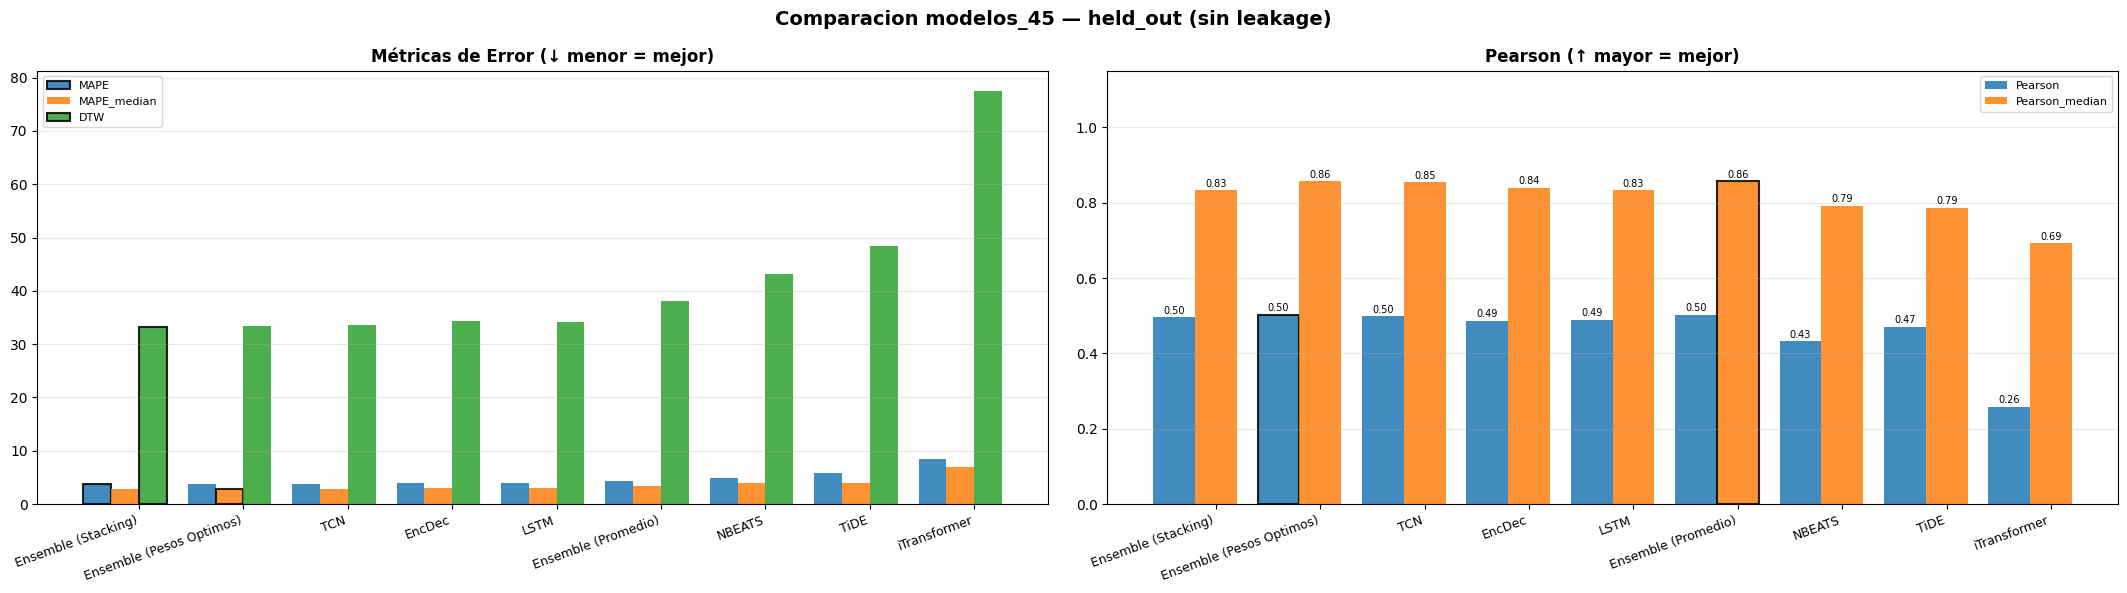

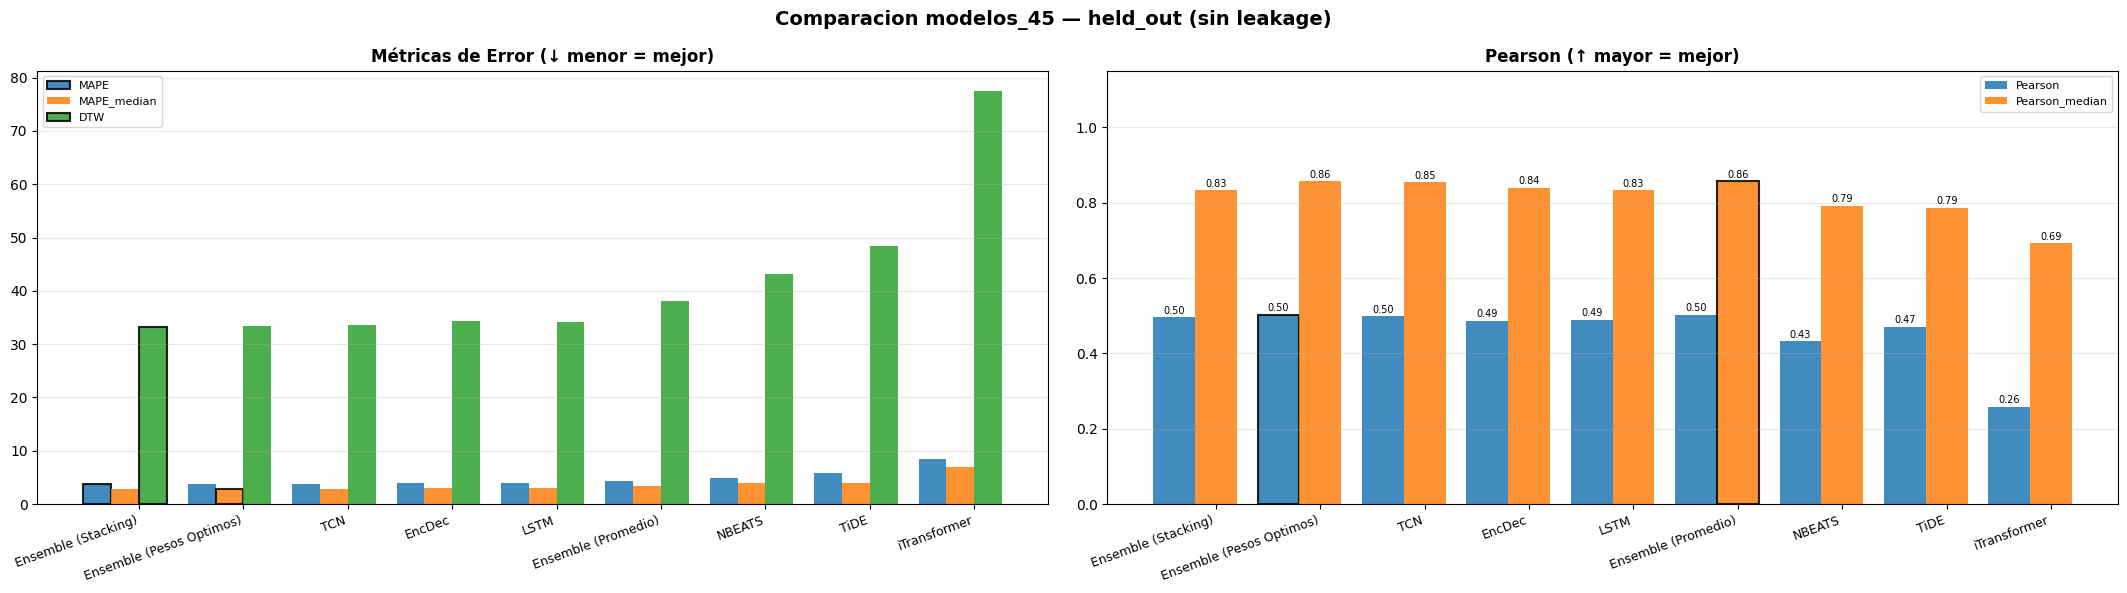

In [49]:
import importlib, utils as _utils_mod
importlib.reload(_utils_mod)
import matplotlib.pyplot as plt
%matplotlib inline

utils.plot_metrics_comparison(all_results, title='Comparacion modelos_45 — held_out (sin leakage)')

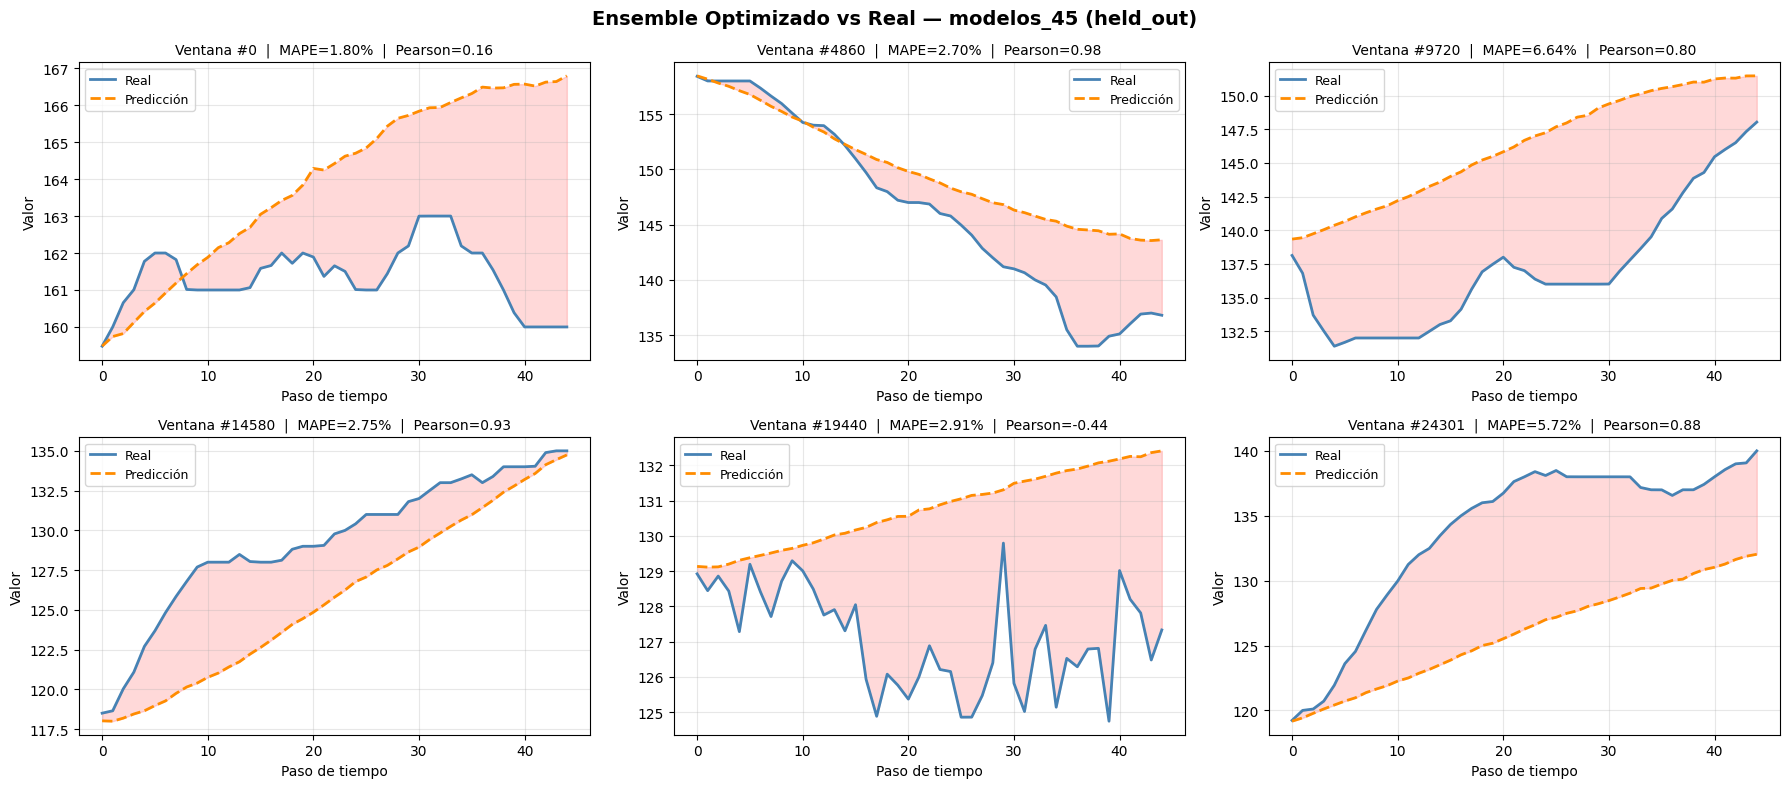

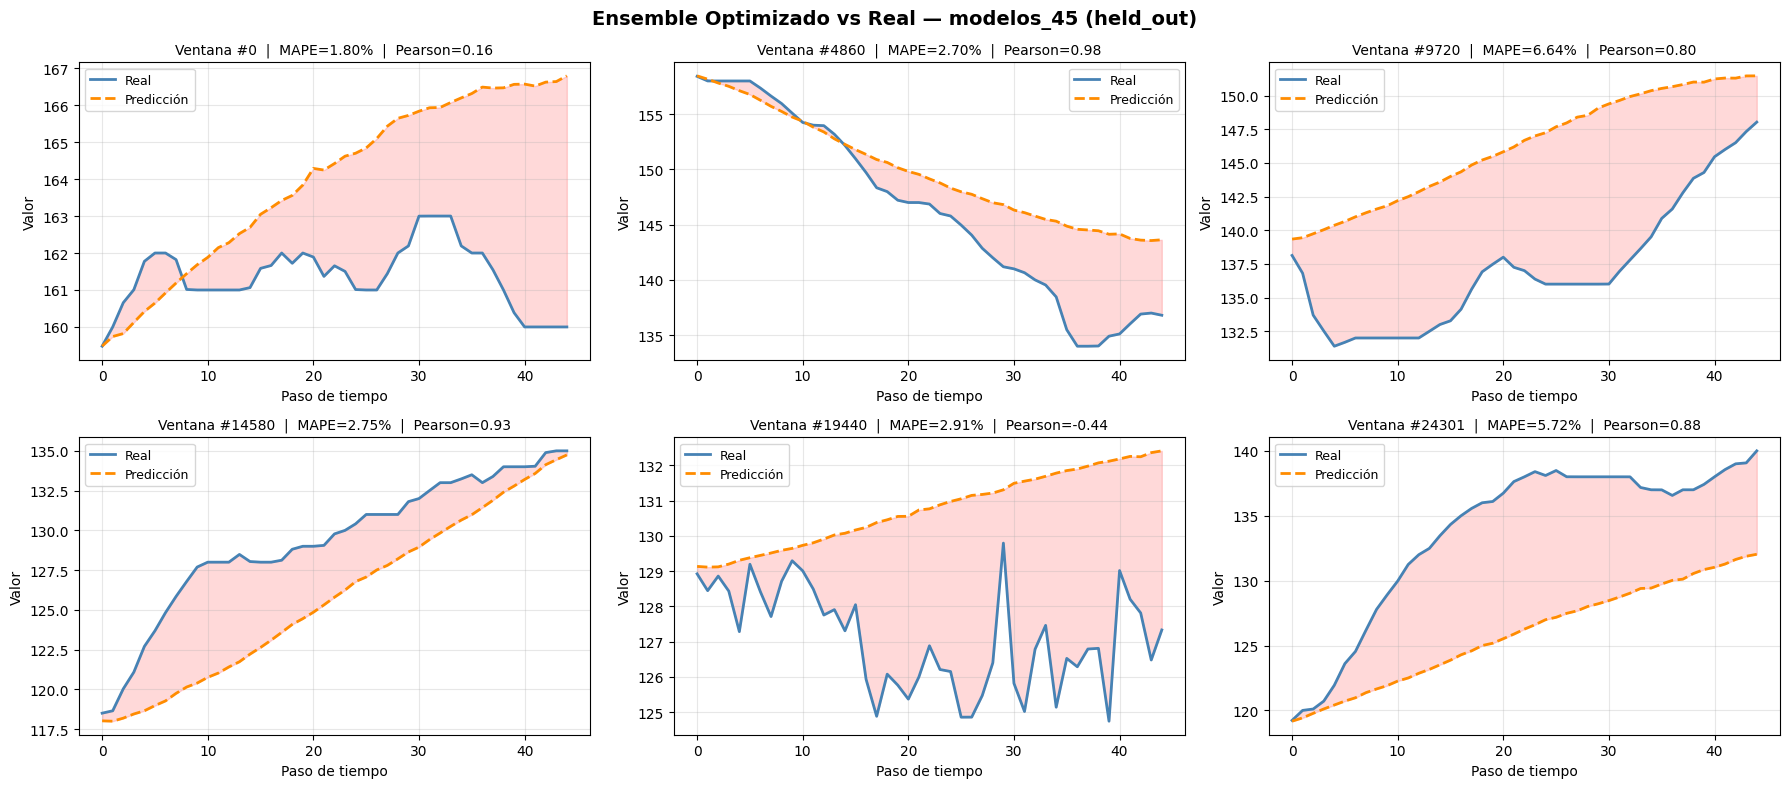

In [50]:
y_ens_pred = ens.predict()

utils.plot_forecast_samples(
    y_held_out_orig, y_ens_pred, n_samples=6,
    title='Ensemble Optimizado vs Real — modelos_45 (held_out)'
)

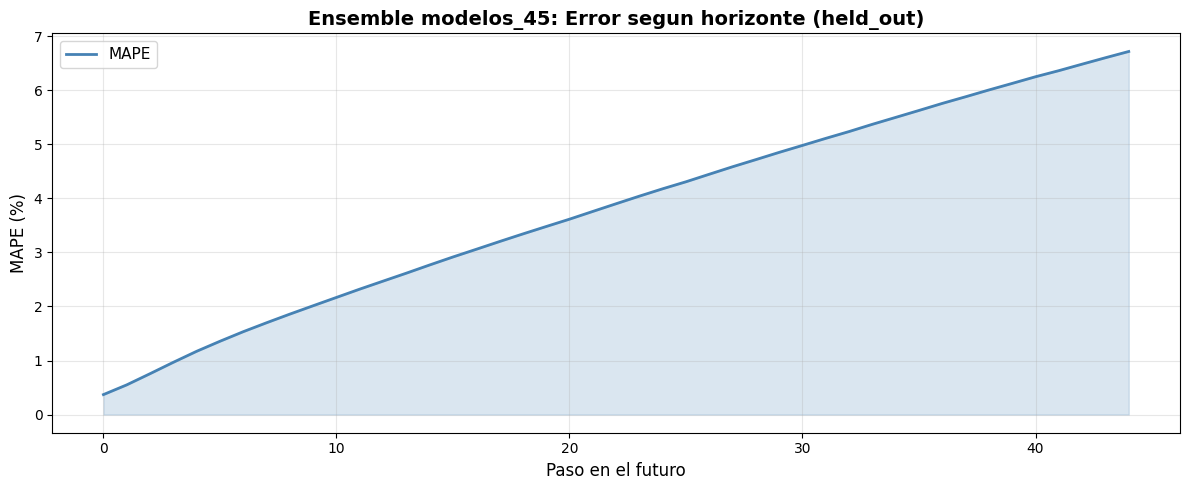

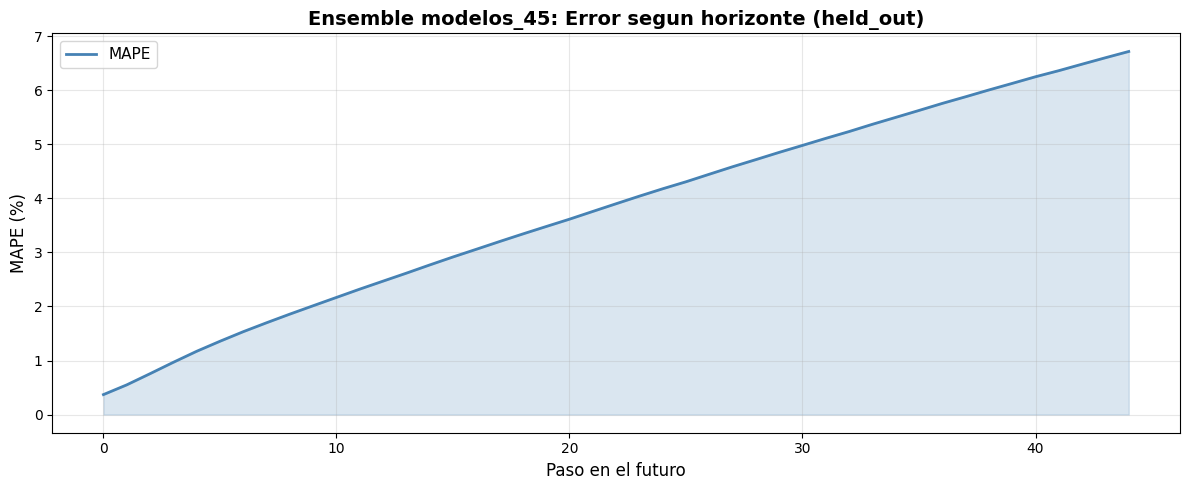

In [51]:
utils.plot_error_over_horizon(
    y_held_out_orig, y_ens_pred,
    title='Ensemble modelos_45: Error segun horizonte (held_out)'
)

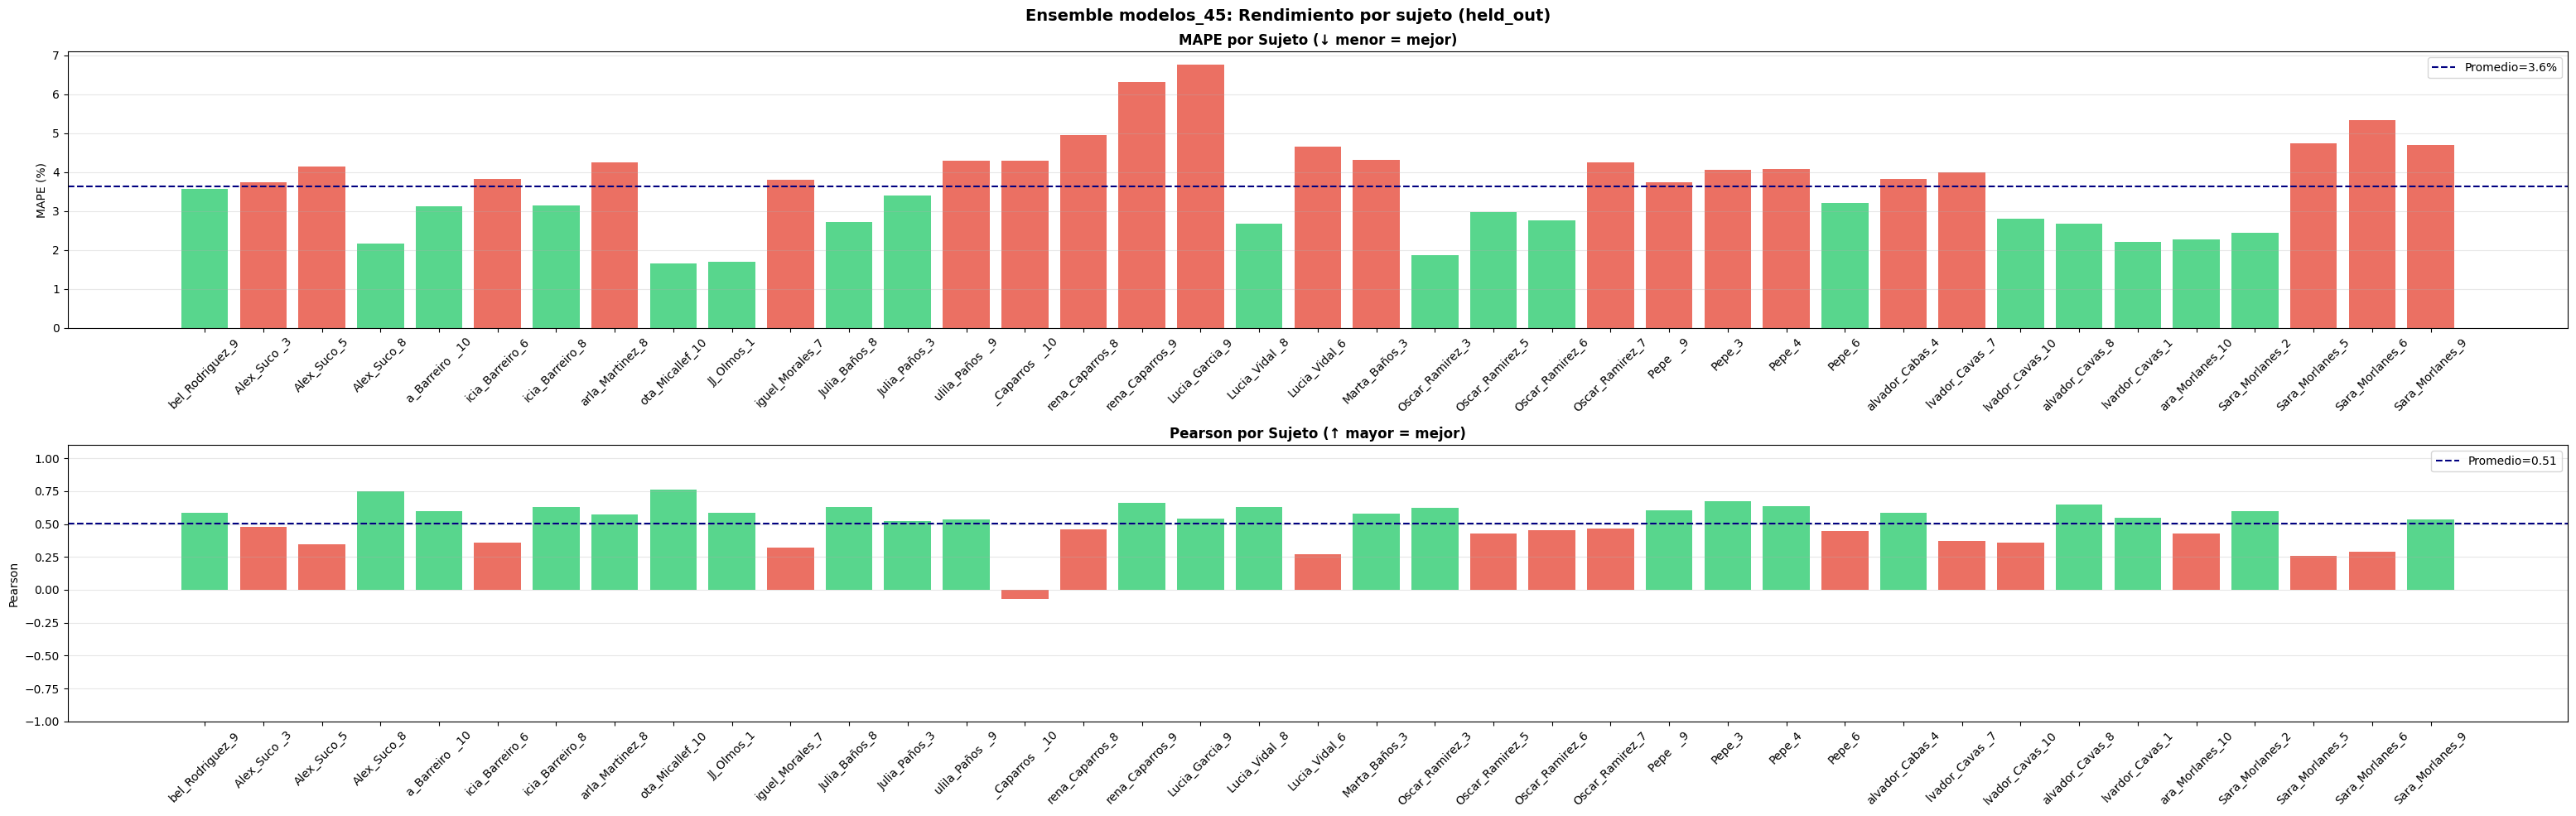

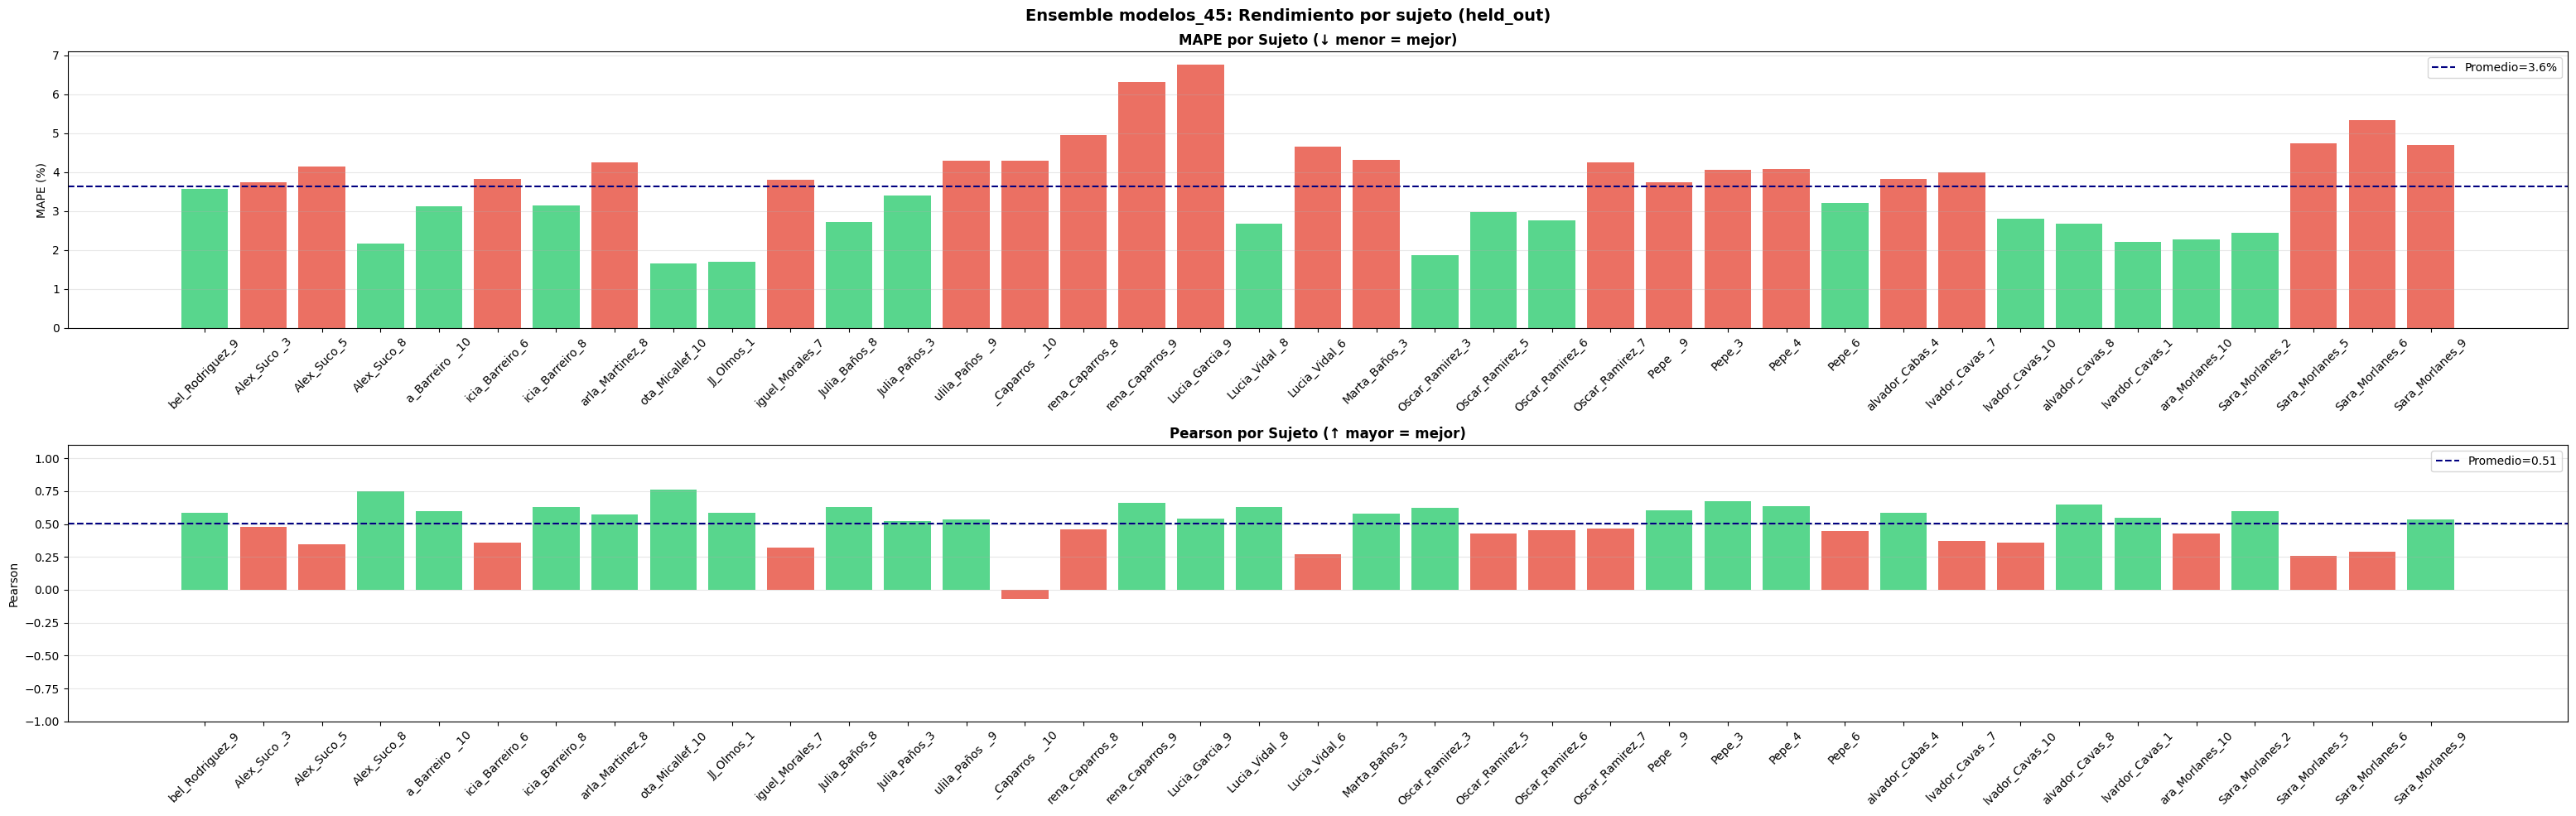

In [52]:
utils.plot_subject_performance(
    y_held_out_orig, y_ens_pred, ids_held_out,
    title='Ensemble modelos_45: Rendimiento por sujeto (held_out)'
)

## 9. Diagnostico de overfitting del ensemble

Si el ensemble funciona mucho mejor en `ens_fit` que en `held_out`, hay overfitting en los pesos.

In [53]:
# Evaluar el ensemble (con los mismos pesos) sobre ens_fit
y_ens_on_fit = ens.predict(model_predictions=preds_ens_fit_orig)
metrics_on_fit = utils.evaluate_all_metrics(y_ens_fit_orig, y_ens_on_fit)

# Evaluar sobre held_out
metrics_on_held = utils.evaluate_all_metrics(y_held_out_orig, y_ens_pred)

diag = pd.DataFrame({
    'ens_fit (pesos aprendidos aqui)': metrics_on_fit,
    'held_out (nunca visto)': metrics_on_held,
})

print('=== Diagnostico de overfitting ===')
print('Si MAPE en ens_fit << held_out -> overfitting en pesos del ensemble')
print('Si son similares -> los pesos generalizan bien')
print()
diag

  Evaluation Metrics
  Ventanas evaluadas   : 24301
  MAPE                : 3.8301
  MAPE_median         : 2.8795
  DTW                 : 33.7009
  Pearson             : 0.5059
  Pearson_median      : 0.8545
  Evaluation Metrics
  Ventanas evaluadas   : 24302
  MAPE                : 3.801
  MAPE_median         : 2.8505
  DTW                 : 33.3687
  Pearson             : 0.5031
  Pearson_median      : 0.8563
=== Diagnostico de overfitting ===
Si MAPE en ens_fit << held_out -> overfitting en pesos del ensemble
Si son similares -> los pesos generalizan bien



,ens_fit (pesos aprendidos aqui),held_out (nunca visto)
MAPE,3.8301,3.8010
MAPE_median,2.8795,2.8505
DTW,33.7009,33.3687
Pearson,0.5059,0.5031
Pearson_median,0.8545,0.8563
